# 📘 S6_P2_housing — Random Forest COMPLET : GridSearch, importance des features & SHAP

## 🎯 Ce que tu vas apprendre
La **version aboutie** de S6_P2 (qui s'arrêtait en route). On reprend la forêt aléatoire et on va jusqu'au bout de l'analyse professionnelle :
1. Récupérer le meilleur modèle du GridSearch (`best_estimator_`) et l'évaluer
2. L'**importance des features** (quelles variables comptent le plus)
3. **SHAP** : la technique moderne d'**explicabilité** — comprendre CHAQUE prédiction

## 📖 Toujours le dataset `Housing_2.csv`
Le même terrain que S6_P1/S6_P2, pour boucler la comparaison des modèles.

---
Import de pandas.

In [1]:
import pandas as pd

Chargement du CSV.

In [2]:
df = pd.read_csv("../Data/Housing_2.csv")

Prix en millions (⚠️ pas deux fois).

In [3]:
df["price"] = df["price"]/1000000

Features `X`.

In [4]:
X = df.drop("price", axis=1)

Cible `y`.

In [5]:
y = df["price"]

Import de `train_test_split`.

In [6]:
from sklearn.model_selection import train_test_split

Split 80/20.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=32)

Forme du train : (436, 12) ✅.

In [8]:
print(f"Training set_shape {X_train.shape} {y_train.shape}")

Training set_shape (436, 12) (436,)


Forme du test : (109, 12) ✅.

In [9]:
print(f"Training set_shape {X_test.shape} {y_test.shape}")

Training set_shape (109, 12) (109,)


Imports : RandomForest, RMSE, numpy (théorie de la forêt détaillée en S6_P2, étape 8 : N arbres qui votent).

In [10]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error
import numpy as np

## Étape — Une GROSSE forêt

`RandomForestRegressor(n_estimators=500, max_depth=60, random_state=32)` : **500 arbres**, profondeur quasi illimitée (60).

💡 **Pourquoi la profondeur élevée ne fait pas surapprendre ici ?** C'est la magie de la forêt : même si chaque arbre individuel surapprend (profondeur 60), la **moyenne de 500 arbres variés** lisse ce surapprentissage. C'est la différence clé avec l'arbre unique de S6_P1 (où depth 20 était catastrophique). La forêt est bien plus tolérante à `max_depth`.

In [11]:
RF = RandomForestRegressor(n_estimators=500, max_depth=60, random_state=32)
RF.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",60
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

Prédiction sur le test.

In [12]:
y_pred_RF = RF.predict(X_test)

RMSE ≈ **0.943** — comme la forêt de 30 arbres de S6_P2 (0.945) ! Preuve que passer de 30 à 500 arbres et de depth 5 à 60 n'a quasiment rien changé : la forêt avait déjà convergé. Plus d'arbres ≠ toujours mieux ; ça plafonne.

In [13]:
rmse_RF = root_mean_squared_error(y_test, y_pred_RF)
print(f"RMSE: {rmse_RF}")

RMSE: 0.943070355964823


Prix moyen du test ≈ 4.80 M.

In [14]:
np.mean(y_test)

np.float64(4.799816513761469)

Erreur relative ≈ **0.196** (~20 %) — le bon réflexe (RMSE ÷ moyenne).

In [15]:
print(f"Relative Root Mean Squarred Error: {rmse_RF / np.mean(y_test)}")

Relative Root Mean Squarred Error: 0.19648050154854102


Import de SuperTree.

In [16]:
from supertree import SuperTree

Objet SuperTree sur la forêt.

In [17]:
super_tree = SuperTree(RF, X, y.values, list(X.columns.values))

Exploration d'un arbre de la forêt (rappel S6_P2 : la forêt prédit par la moyenne, un arbre seul est indicatif).

In [18]:
super_tree.show_tree()

Import de `GridSearchCV`.

In [19]:
from sklearn.model_selection import GridSearchCV

## Étape — La recherche en grille (théorie complète en S6_P2, étape 19)

Grille : `max_depth` ∈ {10,20,30} × `n_estimators` ∈ {50,100,150,200} = 12 combinaisons × CV 5 = 60 entraînements. `scoring="neg_root_mean_squared_error"` (négatif car sklearn maximise).

In [20]:
model_rf = RandomForestRegressor(random_state=32)
param_grid = {"max_depth": [10, 20, 30], "n_estimators": [50, 100, 150, 200]}
grid_search = GridSearchCV(estimator=model_rf, param_grid=param_grid, cv=5, scoring="neg_root_mean_squared_error")

Lancement de la recherche (l'étape longue : 60 forêts entraînées).

In [21]:
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=32)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, 20, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the s

Résultats détaillés de la CV en DataFrame.

In [22]:
results = pd.DataFrame(grid_search.cv_results_)

Colonne `RMSE` positive (inversion du signe).

In [23]:
results["RMSE"] = -results["mean_test_score"]

Import de `plotly.graph_objects`.

In [24]:
import plotly.graph_objects as go

`best_params_` → **{max_depth: 10, n_estimators: 150}** — identique à S6_P2. Robuste : la meilleure config ne dépend pas du hasard.

In [25]:
print(f"Best parameters: {grid_search.best_params_}")

Best parameters: {'max_depth': 10, 'n_estimators': 150}


`best_score_` ≈ −1.188 (RMSE CV ~1.19, plus honnête que le 0.94 sur un seul split).

In [26]:
print(f"Best RMSE: {grid_search.best_score_}")

Best RMSE: -1.1882628832659416


Pivot en tableau 2D (profondeurs × n_estimators).

In [27]:
surface = results.pivot(index="param_max_depth", columns="param_n_estimators", values="RMSE")

Aperçu de la surface des RMSE.

In [28]:
surface

param_n_estimators,50,100,150,200
param_max_depth,,,,
10,1.206159,1.194456,1.188263,1.189341
20,1.201821,1.199121,1.191826,1.193975
30,1.202287,1.199268,1.191986,1.194116


Tri des index pour une surface 3D propre.

In [29]:
surface = surface.sort_index().sort_index(axis=1)

Surface 3D interactive (cf. S6_P2, étape 30 : chercher la vallée = la meilleure combinaison).

In [30]:
go.Figure(data=[go.Surface(x=surface.columns.astype(int),
                           y=surface.index.astype(int),
                           z=surface.values)]).show()

## ✅ Étape — Récupérer et évaluer le MEILLEUR modèle (ce qui manquait à S6_P2 !)

`model_grid = grid_search.best_estimator_` — **l'attribut correct** (S6_P2 s'était arrêté sur `.best`, incomplet !). `best_estimator_` est la forêt déjà ré-entraînée avec les meilleurs hyperparamètres, prête à l'emploi.

`root_mean_squared_error(y_test, pred_grid)` ≈ **0.932** : le modèle optimisé fait **mieux** (0.932) que la forêt réglée à la main (0.943). Le GridSearch a gagné un petit gain — modeste ici, mais c'est la méthode rigoureuse.

In [31]:
model_grid = grid_search.best_estimator_
pred_grid = model_grid.predict(X_test)
root_mean_squared_error(y_test, pred_grid)

0.9317909904465623

Affichage du modèle retenu : `RandomForestRegressor(max_depth=10, n_estimators=150)` — la config gagnante.

In [32]:
model_grid

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",150
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

SuperTree sur le modèle optimisé.

In [33]:
super_tree = SuperTree(model_grid, X, y.values,  list(X.columns.values))

## Étape — L'importance des features

`model_grid.feature_importances_` : comme pour un arbre seul (S4_P2), la forêt calcule la contribution de chaque variable — mais **moyennée sur les 150 arbres**, donc bien plus **fiable et stable** qu'avec un arbre unique. C'est un des grands avantages des forêts.

In [34]:
feature_importance = model_grid.feature_importances_

Récupération des noms de colonnes.

In [35]:
features = X.columns

## 🔍 Le graphique d'importance

`importance_df` trié + `.plot.bar(x="Feature")` : les variables classées de la plus à la moins importante.

**🔍 Ce que tu dois voir :** `area` (surface) domine largement, suivie probablement de `bathrooms`, `airconditioning`, `stories`… Les variables oui/non peu discriminantes (guestroom, basement…) ferment la marche. C'est cohérent avec toute l'analyse du cours : la surface est LE facteur n°1 du prix d'une maison.

<Axes: xlabel='Feature'>

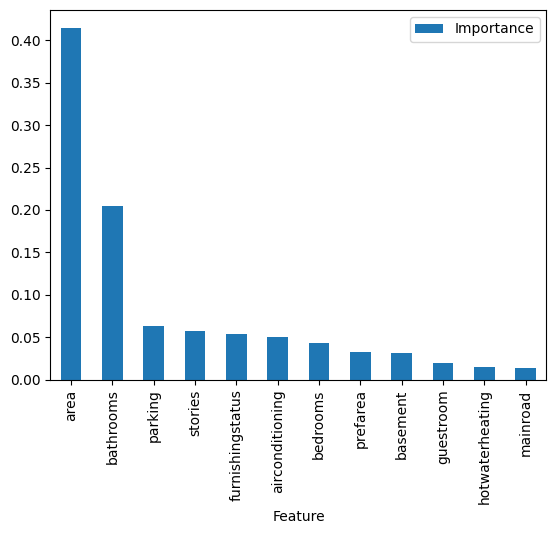

In [36]:
importance_df = pd.DataFrame({"Feature": features, "Importance": feature_importance})
importance_df = importance_df.sort_values(by="Importance", ascending=False)
importance_df.plot.bar(x = "Feature")

## ⭐ Étape — Installer SHAP : l'explicabilité de pointe

`%pip install shap`. **SHAP** (*SHapley Additive exPlanations*) est LA technique moderne pour expliquer les modèles « boîte noire » comme les forêts.

In [37]:
%pip install shap


   -------------------------- ------------- 2/3 [shap]
   -------------------------- ------------- 2/3 [shap]
   -------------------------- ------------- 2/3 [shap]
   ---------------------------------------- 3/3 [shap]

Note: you may need to restart the kernel to use updated packages.


## 🧠 THÉORIE — SHAP : au-delà de l'importance des features

L'importance des features dit « area compte beaucoup » **en général**. SHAP va bien plus loin : pour **CHAQUE prédiction individuelle**, il calcule combien **chaque variable a poussé le prix vers le haut ou vers le bas** par rapport à la moyenne.

L'idée vient de la **théorie des jeux** (les *valeurs de Shapley*, prix Nobel d'économie) : on traite les features comme des « joueurs » qui coopèrent pour produire la prédiction, et on répartit équitablement leur contribution.

`shap.TreeExplainer(model_grid)` crée un « explicateur » optimisé pour les modèles à base d'arbres (rapide et exact pour les forêts).

In [40]:
import shap
explainer = shap.TreeExplainer(model_grid)

`explainer.shap_values(X_test)` calcule, pour chaque maison du test ET chaque feature, sa **valeur SHAP** (sa contribution signée à la prédiction de cette maison précise).

In [41]:
shap_values = explainer.shap_values(X_test)

## 📊 Le summary_plot : la synthèse SHAP

`shap.summary_plot(shap_values, X_test)` — le graphique roi de SHAP. Comment le lire :
- **chaque point** = une maison, pour une feature donnée,
- **axe horizontal** = la valeur SHAP (à droite = pousse le prix ↑, à gauche = pousse le prix ↓),
- **couleur** = la valeur de la feature (rouge = élevée, bleu = basse),
- **les features** sont classées par importance globale (haut = plus influente).

**🔍 Le motif typique pour `area` :** les points rouges (grande surface) à droite (prix ↑), les points bleus (petite surface) à gauche (prix ↓) — une belle séparation qui confirme « plus grand = plus cher », mais **maison par maison**. SHAP répond à « POURQUOI le modèle a prédit CE prix pour CETTE maison » — l'explicabilité individuelle, essentielle en pratique (banque, médecine, où il faut justifier chaque décision).

## 📝 Résumé du notebook — l'aboutissement du cours
1. **`best_estimator_`** : récupérer et évaluer le modèle optimisé du GridSearch (0.932, ce qui manquait à S6_P2).
2. La forêt tolère une grande profondeur (500 arbres depth 60 = 30 arbres depth 5) — la moyenne lisse le surapprentissage.
3. **`feature_importances_`** (moyennée sur 150 arbres = stable) : `area` domine.
4. **SHAP** : l'explicabilité par prédiction individuelle (valeurs de Shapley), au-delà de l'importance globale.
5. **Le classement final sur Housing** : Random Forest (~0.93) > Régression linéaire (1.11) > Arbre optimal (1.17) > Arbre libre (1.49). La forêt est championne. 🏆

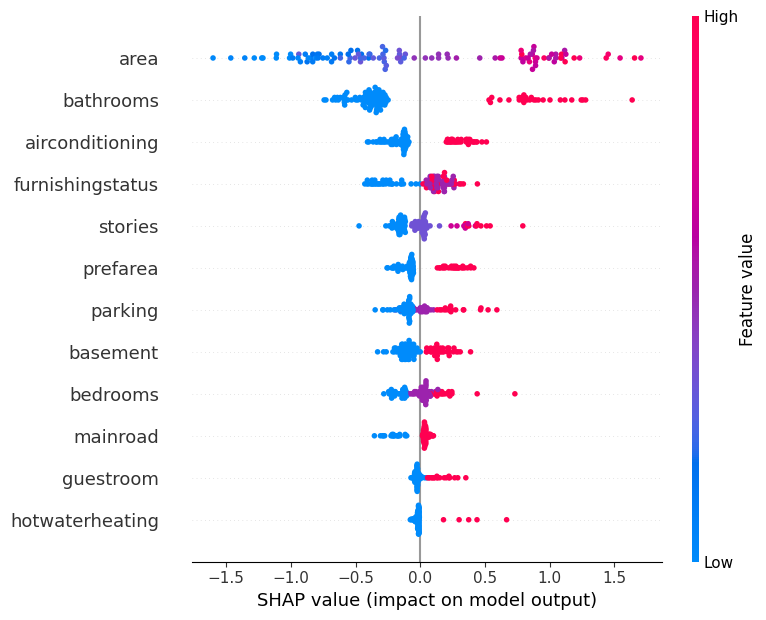

In [42]:
shap.summary_plot(shap_values,X_test)